In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

Task 1 — Data Exploration with Pandas
Load the dataset: df = pd.read_csv("students.csv") 
using pandas pd.read student file save on my local directory is ready in env
head -show first 5 records

In [57]:


df = pd.read_csv(r"C:\pramod\New start of career\lectures\Assigment 3\Python-assignment-part4\student.csv")

print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


2/Print the shape (rows × columns) and the data type of each column using .dtypes
shap show row and columns
dtypes show type of each value whether number, text,boolen etc etc


In [4]:
print(df.shape)
print(df.dtypes)

(15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


3.Print summary statistics (mean, min, max, std) for all numeric columns using .describe()
describe show require value

In [5]:
print(df.describe())

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

4.Print the count of students who passed and who failed. (Hint: use df['passed'].value_counts())

In [ ]:
print(df['passed'].value_counts())

passed
1    9
0    6
Name: count, dtype: int64


5.Compute and print the average score per subject
6.Find and print the student with the highest overall average across all 5 subjects

Task 2 — Data Visualization with Matplotlib.
Before starting, add a new column to your DataFrame:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

In [7]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)
print(df.head(10))

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   
5    Frank    60       65       72       58  70              78   
6    Grace    55       48       44       52  62              60   
7    Henry    82       79       85       77  90              88   
8     Iris    70       74       68       65  78              80   
9     Jack    30       35       40       28  45              50   

   study_hours_per_day  passed  avg_score  
0                  4.5       1       86.2  
1                  1.2       0       51.0  
2                  3.0       1       76.2  
3                  6.0       1       94.0  
4                  0.8       0       46.0 

Task 2 — Data Visualization with Matplotlib


using the data shared in LMS under resource lecture 26 .i have use similar code to plot require data. ax method is profression way to plot graphs
first all require libaries are imported
fis size show width and height of graph
numpy linespacing
set title for header
set x and y label
plt show 
save fig to save png file on local drive
all graph made using ax.bar,ax.hist,ax.scatter.ax.box,ax.line


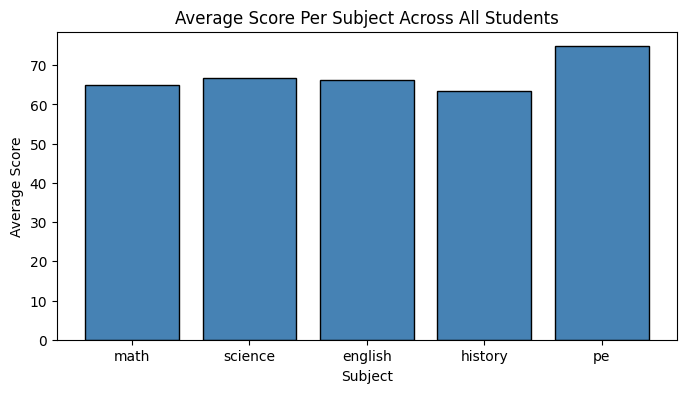

plot1_bar.png saved!


<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
subject_cols = ['math', 'science', 'english', 'history', 'pe']
avg_per_subject = df[subject_cols].mean()

fig,ax=plt.subplots(figsize=(8,4))

x=np.linspace(0,10,50)
y=np.sin(x)

ax.bar(avg_per_subject.index, avg_per_subject.values, color='steelblue', edgecolor='black')
ax.set_title('Average Score Per Subject Across All Students')
ax.set_xlabel('Subject')
ax.set_ylabel('Average Score')
plt.show()

plt.savefig('plot1_bar.png')

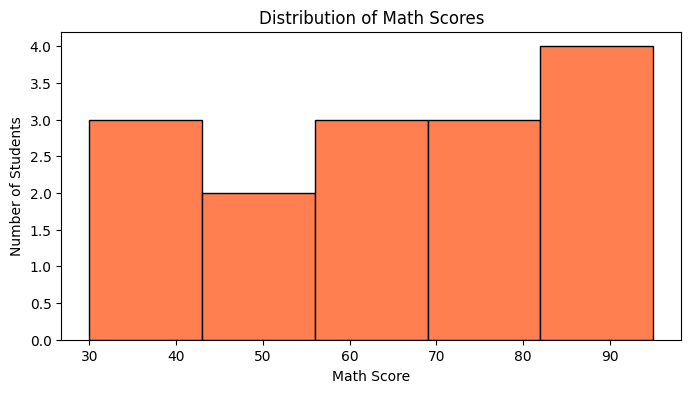

<Figure size 640x480 with 0 Axes>

In [20]:
mean_math = df['math'].mean()

fig,ax=plt.subplots(figsize=(8,4))

x=np.linspace(0,10,50)
y=np.sin(x)

ax.hist(df['math'], bins=5, color='coral', edgecolor='black')
ax.set_title('Distribution of Math Scores')
ax.set_xlabel('Math Score')
ax.set_ylabel('Number of Students')
plt.show()
plt.savefig('plot2_histogram.png')


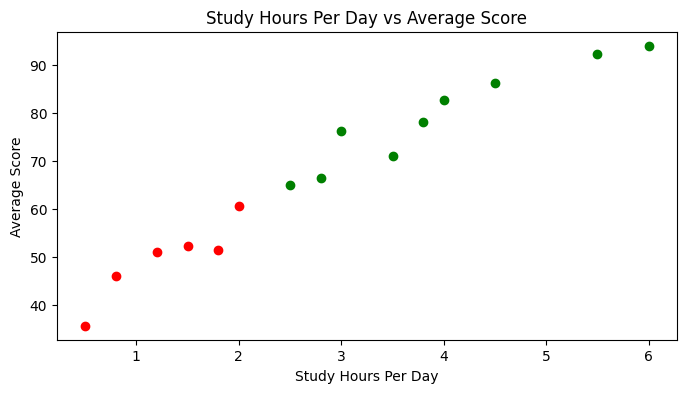

In [23]:
fig,ax=plt.subplots(figsize=(8,4))

x=np.linspace(0,10,50)
y=np.sin(x)
passed_df = df[df['passed'] == 1]
failed_df = df[df['passed'] == 0]

ax.scatter(passed_df['study_hours_per_day'], passed_df['avg_score'],
            color='green')
ax.scatter(failed_df['study_hours_per_day'], failed_df['avg_score'],
            color='red',)
ax.set_title('Study Hours Per Day vs Average Score')
ax.set_xlabel('Study Hours Per Day')
ax.set_ylabel('Average Score')
plt.savefig('plot3_scatter.png')
plt.show()


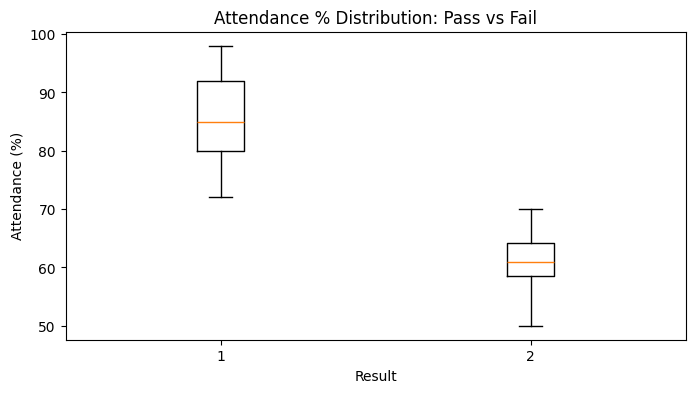

<Figure size 640x480 with 0 Axes>

In [30]:
fig,ax=plt.subplots(figsize=(8,4))

x=np.linspace(0,10,50)
y=np.sin(x)

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()


ax.boxplot([pass_attendance, fail_attendance])
            
ax.set_title('Attendance % Distribution: Pass vs Fail')
ax.set_xlabel('Result')
ax.set_ylabel('Attendance (%)')
plt.show()
plt.savefig('plot4_boxplot.png')





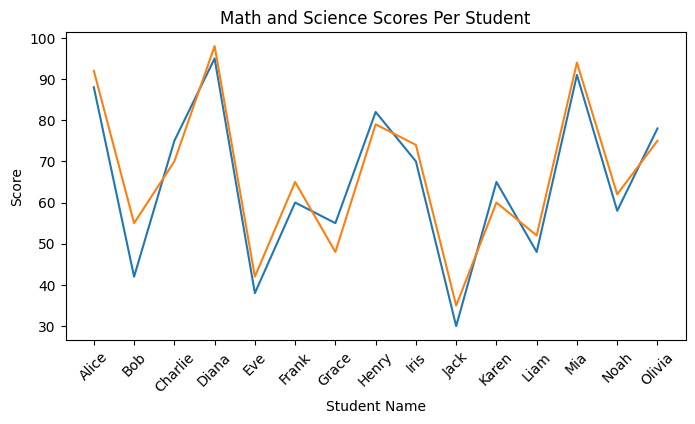

In [31]:
fig,ax=plt.subplots(figsize=(8,4))

x=np.linspace(0,10,50)
y=np.sin(x)

ax.plot(df['name'], df['math'])
ax.plot(df['name'], df['science'])
ax.set_title('Math and Science Scores Per Student')
ax.set_xlabel('Student Name')
ax.set_ylabel('Score')
plt.xticks(rotation=45)

plt.savefig('plot5_lineplot.png')
plt.show()


Task 3 — Data Visualization with Seaborn

i tried using method given LMS information shared didnt work

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


x=np.linspace(0,10,50)
y=np.sin(x)
category=[1:'passed', 0:'fail']

df=pd.dataframe({'x'='passed_label', 'y'='math','category':category})
sns.lineplot(data=df,x='x',y='y',hue='category')
plt.title('average math score')





SyntaxError: invalid syntax (3147814793.py, line 8)

4.matplotlib is best for custom,publication-quality charts and steepr learning curve
seaborni is quick EDA and gentler 

Task 4 — Machine Learning with scikit-learn 

i have use file given resources Scikit-Learn and Visualization
import all libaries 
x and y is defind
then test run as per information shared




In [52]:
import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

Features=['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
target = ['passed']
X= df[Features]
y= df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


3.Scale features using StandardScaler — fit on training data only, then transform both sets:

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Step 2 — Train a Model:

Train a LogisticRegression model on the scaled training data.
Print the model's training accuracy.


In [53]:
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 1.0


c:\Users\Pramod\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Step 4 — Feature Importance:

In [54]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [56]:
coefficients = model.coef_[0]
print(coefficients)

[0.43794393 0.32300976 0.8125128  0.26292893 0.47497406 0.52187634
 0.48443266]
